#### CS323: Digital Image Processing
#### Course Project
#### Academic Year 2025-2026, Second Semester

### Group information:
#### Section: 84

#### Members: 
1. Raihanah AlAli 223007420
2. Habiba Hany 223049808
3. Sarah Alawad 223043808

## Challenge 01: Image Enhancement

### Description

Image enhancement is a fundamental process in digital image processing that aims to improve the visual appearance of an image or to provide a better transform representation for future automated image processing. The goal of this challenge is to enhance the quality of a specific image by adjusting its brightness, contrast, and clarity through various spatial domain techniques, making it more suitable for human perception and analysis.

### Challenge

Apply different image enhancement techniques to improve image quality and visibility. Compare the results using techniques such as Gamma Correction, Global Histogram Equalization, and Contrast Limited Adaptive Histogram Equalization (CLAHE), in addition to Gaussian blurring as a preprocessing or smoothing step.

### Part i — Libraries:

cv2 (OpenCV): The primary library used for reading images, color space conversions (BGR to RGB/Gray), and implementing enhancement algorithms like Histogram Equalization and CLAHE.

numpy as np: Used for numerical operations, specifically for applying the power-law transformation in Gamma Correction.

matplotlib.pyplot as plt: Used for displaying the original and processed images in a comparative grid layout.

### Part ii — User-Defined Functions:

plot_image(image, title)
A helper function that wraps imshow, set_title, and axis('off'). This prevents code redundancy and ensures a consistent visual style when displaying multiple enhancement results in subplots.

### Part iii — Image Conversion:

cv2.COLOR_BGR2RGB: Since OpenCV loads images in BGR format by default, this conversion is necessary to ensure colors are displayed correctly (RGB) when using Matplotlib.

BGR to Individual Channels: For Histogram-based techniques, the image is often split into its three color channels to apply the enhancement to each channel independently before merging them back.

### Part iv — Image Preparation:

Before applying certain enhancements, Gaussian Blur is used as a smoothing technique. It helps in reducing high-frequency noise that might be amplified during contrast enhancement processes, ensuring that the final output looks natural and clear.

### Part v — Code Explanation:

#### Part 1 — DIP Techniques Used:

1. Gaussian Blur: A smoothing filter used to reduce image noise and detail. It works by convolving the image with a Gaussian kernel, which is effective for preparing the image for further processing.

2. Gamma Correction: A non-linear operation used to encode and decode luminance. By applying the formula O=(I/255)γ×255, we can adjust the brightness of the image to recover details in dark or overexposed areas.

3. Global Histogram Equalization: This technique improves contrast by spreading out the most frequent intensity values. It calculates the cumulative distribution function (CDF) to stretch the histogram across the entire range (0-255).

4. CLAHE (Contrast Limited Adaptive Histogram Equalization): An advanced version of histogram equalization that operates on small regions (tiles) rather than the whole image. It limits contrast amplification to prevent noise over-amplification, making it ideal for local detail enhancement.

#### Part 2 — Additional Methods:

cv2.split() & cv2.merge(): Used to separate the color channels for individual processing and combine them back after enhancement.

cv2.createCLAHE(): Initializes the CLAHE operator with specific parameters like clipLimit and tileGridSize.

np.array(..., dtype='uint8'): Ensures the pixel values remain within the valid 8-bit range (0-255) after mathematical transformations.

#### Part 3 — Difficulty Faced:

The main challenge was balancing the contrast enhancement in CLAHE. Setting a high clipLimit resulted in unwanted noise in the background, while a very low limit didn't provide enough enhancement. After several trials, a clipLimit=2.0 was selected as it provided the best balance between clarity and natural appearance.

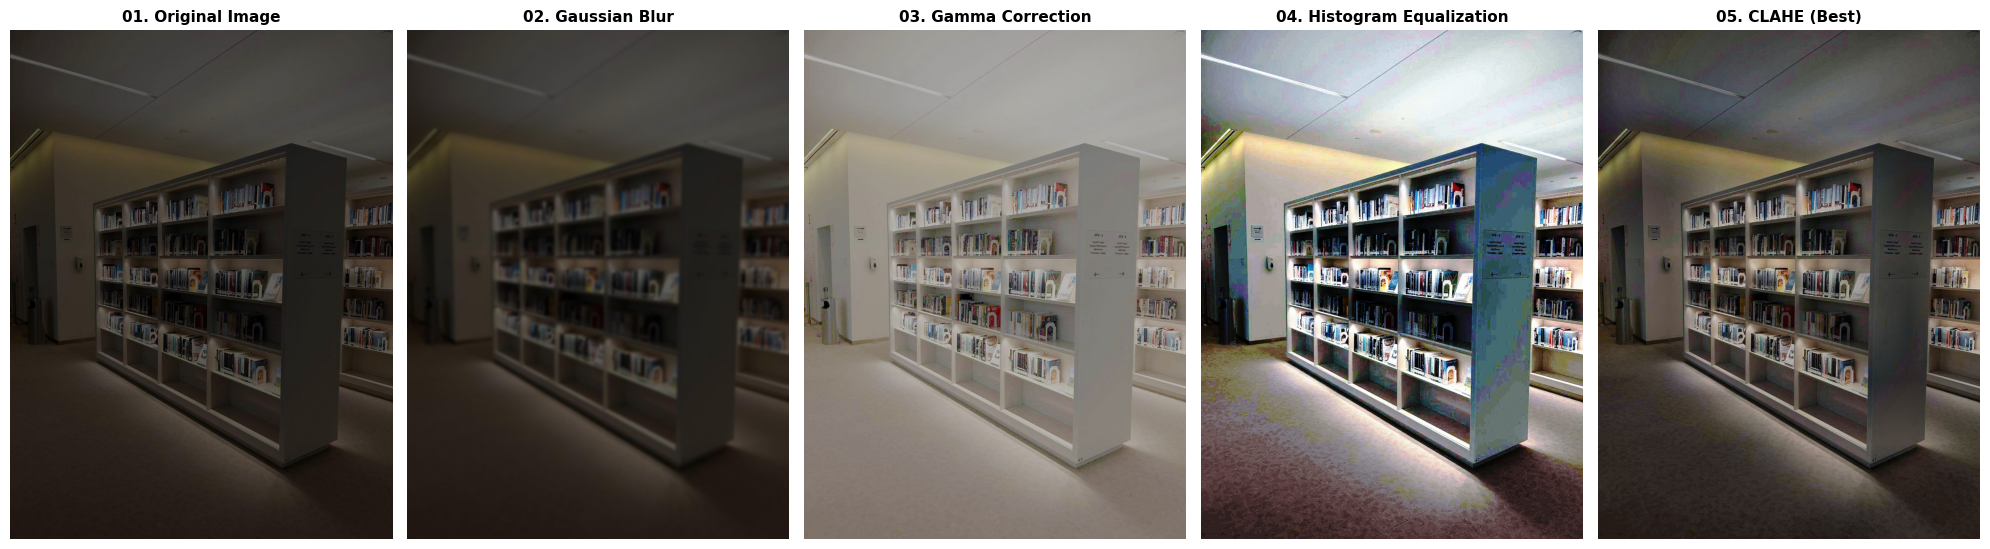

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the original image
image_bgr = cv2.imread("images/challenge_1.jpeg")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 2. Image Enhancement & Processing Techniques

# --- Gaussian Blur (Blurring/Smoothing) ---
# Considered the "worst" in terms of detail clarity as it removes edge information
image_blurred_bgr = cv2.GaussianBlur(image_bgr, (25, 25), 0)
image_blurred_rgb = cv2.cvtColor(image_blurred_bgr, cv2.COLOR_BGR2RGB)

# --- Gamma Correction (Brightness Adjustment) ---
# Improving visibility by adjusting pixel intensity
gamma = 3.0
image_gamma_correction = np.array(255 * (image_bgr / 255) ** (1.0 / gamma), dtype='uint8')
image_gamma_rgb = cv2.cvtColor(image_gamma_correction, cv2.COLOR_BGR2RGB)

# Split channels for contrast enhancement
channels = cv2.split(image_bgr)

# --- Global Histogram Equalization ---
# Enhancing contrast globally across the entire image
hist_channels = [cv2.equalizeHist(ch) for ch in channels]
hist_eq_rgb = cv2.cvtColor(cv2.merge(hist_channels), cv2.COLOR_BGR2RGB)

# --- CLAHE (Adaptive Histogram Equalization) ---
# The best result as it enhances local contrast while preserving details
# Updated parameters for maximum brightness and clarity
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_channels = [clahe.apply(ch) for ch in channels]
clahe_rgb = cv2.cvtColor(cv2.merge(clahe_channels), cv2.COLOR_BGR2RGB)

# 3. Visualization: Ordered from Original -> Worst Adjustment -> Best Enhancement
titles = ["01. Original Image", "02. Gaussian Blur", "03. Gamma Correction", "04. Histogram Equalization", "05. CLAHE (Best)"]
images = [image_rgb, image_blurred_rgb, image_gamma_rgb, hist_eq_rgb, clahe_rgb]

plt.figure(figsize=(20, 8))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=11, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Part vi — Comparison of Techniques:

1. Gaussian Blur: Successfully reduced noise but made the image appear "soft" and lost some fine edge details, confirming its role as a smoothing rather than an enhancement tool.

2. Gamma Correction: Improved the overall brightness of the image, making it more visible, but it did not significantly improve the local contrast between different objects.

3. Global Histogram Equalization: Significantly increased the contrast, making the image much brighter. However, it caused some areas to look "washed out" because it applied the same transformation globally.

4. CLAHE: Produced the best and most professional result. It successfully enhanced local details and contrast without the "washed out" effect of global equalization, making the textures and objects in the image appear sharp and well-defined.

## Challenge 02: Edge Detection

### Description
Edge detection plays a key role in finding wall cracks because it helps highlight the exact 
locations where the wall surface changes suddenly. When a wall is smooth, the pixel values 
in an image change gradually. However, a crack creates a sharp change in intensity (from the 
wall surface to the dark line of the crack). Edge detection algorithms are designed to detect 
these sudden changes, so they make cracks appear as clear, thin lines.

### Challenge
Apply basic edge detection techniques to detect object boundaries. Compare results using 
different operators such as Sobel, Prewitt, or Canny
For this challenge I take a photo of a wall with cracks. then Process the image using 
different edge detection techniques to extract the cracks.

### Part i — Libraries:

 - **cv2 (OpenCV)**: The computer vision library used for reading images, converting color spaces, applying blur filters, and running all four edge detection algorithms Sobel, Prewitt through filter2D, Laplacian, and Canny.
- **numpy as np**: Used to manually define the Prewitt kernel matrices as 2D arrays.
- **matplotlib.pyplot as plt**: Used to display and processed images in a grid layout for easy and clear visualization.

### Part ii — User-Defined Functionses:
**plot_image(image, title)**  
A function that include three matplotlib calls:imshow, title, and axis('off') This fiction is used to  prevents repetitive code when displaying multiple images in subplots.

### Part iii — Image Conversion:
- **cv2.COLOR_BGR2RGB** used because OpenCV reads images in BGR by default, but matplotlib expects RGB. so, without this conversion red and blue channels would appear swapped in the plot.

- **cv2.COLOR_BGR2GRAY** it converts the image to a grayscale image. used for edge detection algorithms because it works on intensity gradients, which require a single numerical value per pixel.it the standard pre-processing step before applying any edge detection filter.

### Part iv — Image Preparation:
Before applying edge detection, the grayscale image is smoothed using Gaussian Blur.

using Gaussian Blur if the image contains noise, because it produce large gradients and it may falsely detected as edges. Gaussian blur smooths out this noise by averaging each pixel with its neighbors using a weighted Gaussian kernel.

### Part v — Code Explanation:
#### Part 1 —DIP Techniques Used:

**1.  Prewitt** : Prewitt it is a differential operator for image edge detection, its principle is to realize edge detection by using the difference generated by the gray value of pixels in a specific area . Prewitt operator used 3×3 template to calculate the pixel values in the region.**the implemention in the code:** first the kernels are defined manually using np.array() and then applied with cv2.filter2D(),then the cv2.convertScaleAbs() is applied to both results before combining with cv2.addWeighted() to produce the final gradient map.

**2. Sobel** : Sobel is a discrete differential operator for edge detection , it combines Gaussian smoothing with differential derivation.**the implemention in the code:** first Sobel method applies two 3×3 gradient kernels one for horizontal edges and one for vertical edges ,then the cv2.convertScaleAbs() is applied to both results before combining with cv2.addWeighted() to produce the final gradient map.

**3. Laplacian** :Laplacian detects edges using the second derivative of the image intensity.**the implemention in the code:** first apply gussian filter becasue Laplacian is sensitive to noise then the Laplacian method ,then the cv2.convertScaleAbs() is applied to the results.

**4. Canny** : Canny is one of the most popular edge-detection methods in use today because it is so robust and flexible.It is a multi-step algorithm:
1. Noise Reduction
2. Calculating Intensity Gradient of the Image
3. Suppression of False Edges
4. Hysteresis Thresholding

#### Part 2 —Additional Methods:
- cv2.GaussianBlur() : smooths out this noise
- cv2.convertScaleAbs() :converts float/signed images to uint8 for display after gradient computation
- cv2.addWeighted() :combines x and y Prewitt and Sobel gradients with equal weights 

#### Part 3 — Difficulty Faced:
The difficulty was tuning the Canny thresholds for the image in this challenge.Low threshold values (15, 100) were chosen after testing higher values like (50, 150) which caused parts of the crack to disappear due to insufficient gradient strength.

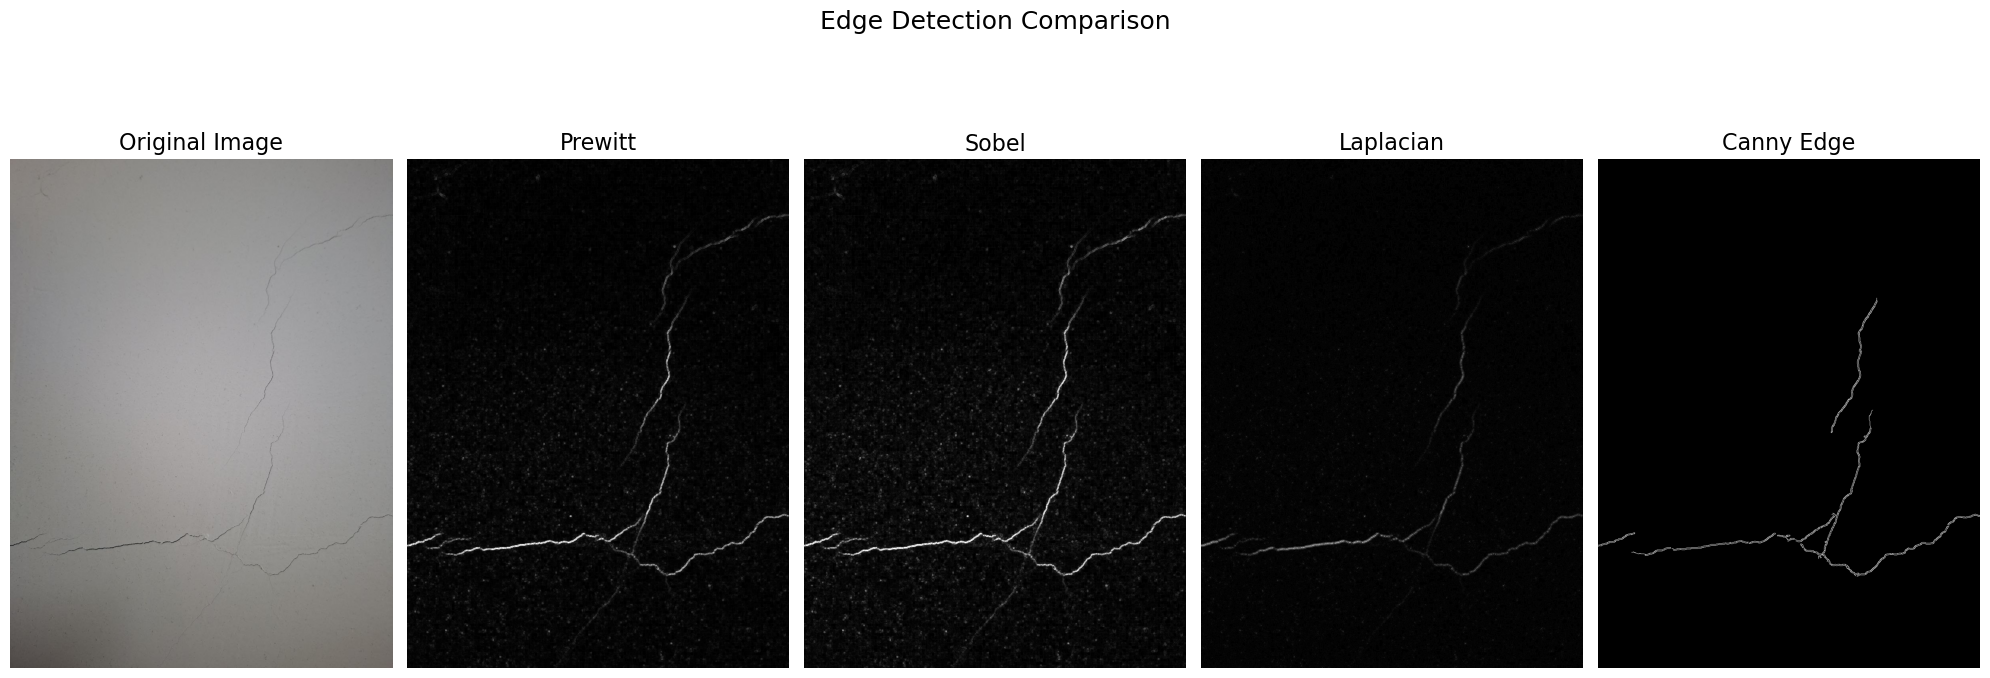

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# function: to display image with title, axes hidden
def plot_image(image, title):
    plt.imshow(image, cmap='gray'), plt.title(title, size=16), plt.axis('off')

# Loading Image 
image = cv2.imread('images/challenge_2.jpg')
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   

# Grayscale Conversion 
grayImage = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Image Preparation: Gaussian Blur
blurred = cv2.GaussianBlur(grayImage, (5, 5), 0)


# 1. Prewitt Edge Detection 
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])   # horizontal kernel
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])   # vertical kernel

x = cv2.filter2D(grayImage, cv2.CV_16S, kernelx)
y = cv2.filter2D(grayImage, cv2.CV_16S, kernely)

absX = cv2.convertScaleAbs(x)
absY = cv2.convertScaleAbs(y)

prewitt = cv2.addWeighted(absX,1,absY,1, 0)

# 2. Sobel Edge Detection
x = cv2.Sobel(grayImage, cv2.CV_16S, 1, 0) 
y = cv2.Sobel(grayImage, cv2.CV_16S, 0, 1) 

SabsX = cv2.convertScaleAbs(x)
SabsY = cv2.convertScaleAbs(y)

Sobel = cv2.addWeighted(SabsX,1,SabsY,1,0) 

# 3. Laplacian Edge Detection 
laplacian = cv2.Laplacian(blurred, cv2.CV_16S, ksize=3)
laplacian_result= cv2.convertScaleAbs(laplacian)

# 4. Canny Edge Detection 
canny = cv2.Canny(blurred, 15, 100, 3, L2gradient=True)

# Display Results 
plt.figure(figsize=(20, 8))

plt.subplot(151), plot_image(img, 'Original Image')
plt.subplot(152), plot_image(prewitt,'Prewitt')
plt.subplot(153), plot_image(Sobel, 'Sobel')
plt.subplot(154), plot_image(laplacian_result, 'Laplacian')
plt.subplot(155), plot_image(canny,'Canny Edge')

plt.suptitle('Edge Detection Comparison',fontsize=18)
plt.tight_layout()
plt.show()


### Part vi — Comparison of Techniques

- **Sobel** successfully highlights the crack as a bright ridge. The crack is clearly visible but not perfectly isolated.

- **Prewitt** produces results visually similar to Sobel,but the response is slightly less pronounced on strong edge.

- **Laplacian** is more sensitive to noise this causes more scattered background detections compared to Sobel and Prewitt. The crack is still visible, but it requires a great thresholding to isolate it from the noise.

- **Canny** produces the clearest result for the challange . The min thresholding eliminates most false detections on the smooth wall, and the max thresholding thins the crack to a clean line. This makes Canny the most suitable technique for structural crack detection.


## Challenge 03. Image Segmentation

### Description:
Image segmentation can be defined as dividing the image into segments by grouping pixels based on similarities in their color, intensity, or texture. Color-based segmentation assumes that homogeneous colors correspond to same region. Segments distribution heavily depends on the number of clusters defined. Nowadays, image segmentation is considered critical for several technologies. For example, AI heavily depends on image segmentaion when it needs to process or analyze an image. Image segmentation enables AI systems to understand digital images as information, such as detecting objects in the image. 

### Challenge:
The challenge is to apply image segmentation techniques to segment a plant into distinct regions.

### Part I - Libraries: 
1. **cv2** library is used to provide common features for computer vision and images applications.
2. **numpy** library is used to create different array objects and perform array manipulations.
3. **matplotlib.pyplot** library is used to show plots visualizations.

### Part II - User-defined functions:  
- `plot_image(image, title)` function plots the result of images. It shows the image, sets the title of the image, and hides the axis.

### Part III - Image Conversion:
The image color is converted from BGR to RGB to display the correct colors of the image.

### Part IV - Image preparation:    
The image is flattend from 3D to 2D array consisting of all pixels as rows and RGB color. Then, the type of the array is converted to  float, so it can be used in `cv2.kmeans()` built-in function.

### Part V - Code Explanation: 
The technique used to segment the picture into distinct regions is K-means clustering. Cv2 has a built-in function to apply the K-means on the image. `cv2.kmeans()` takes serveral parameters: input image as a 2D array of number of pixels and RGB colors, number of clusters, initial lables to clusters, criteria, maximum number of iterations, and a flag to specify how the initial cluster centers are selected.
        
The criteria by which the K-means algorithm will cluster the pixels is declared by specifying the rules and values for them. In this program the rules are maximum number of iterations and epsilon. `cv2.kmeans()` returns 3 values: compactness as the sum of squared distances between centers and points, clusters' labels, and an array of final centroids. 

The difficulty we faced in implementing the K-means is figuring out the best number of clusters to the image. The solution was found by trying some values for the number of clusters by starting with 3 clusters and then incrementing the number of clusters until the best clustered image is found. 

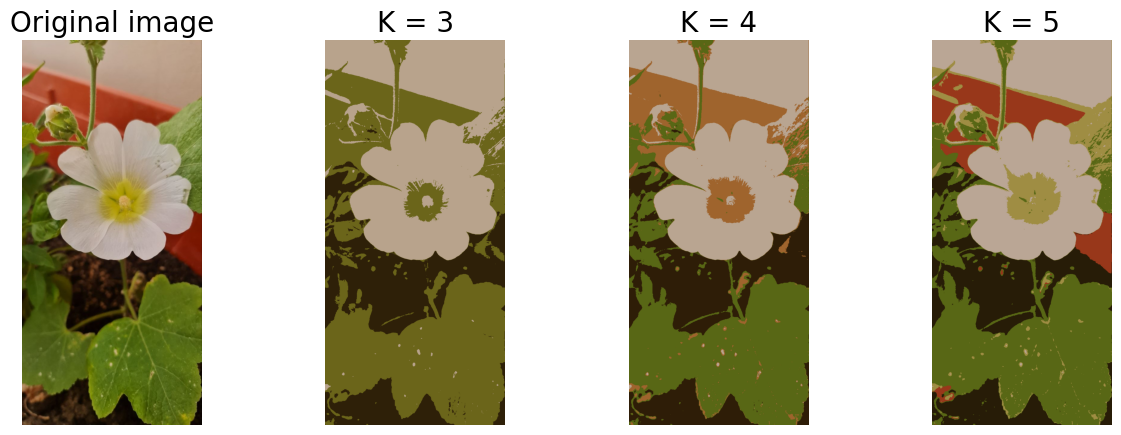

In [10]:
# imported libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# plots an image with the title
def plot_image(image, title):
    plt.imshow(image);
    plt.title(title, size=20);
    plt.axis('off')
    
# read the image and convert the color from BGR to RGB
original_image = cv2.imread('images/challenge_3.jpg') 
image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

vectorized = np.float32(image.reshape((-1,3))) # flatten the image to vector by converting from 3D to 2D then convert it to float

criteria = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 10, 1.0) 

# number of clusters
K1 = 3
K2 = 4
K3 = 5

# number of trials
attempts= 10 

# applying K-means technique to the image
compactness, label, center = cv2.kmeans(vectorized, K1, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

center = np.uint8(center) # convert the array from float to unsigned integer 8-bits
result = center[label.flatten()] # flatten() converts the lables array to 1D array
image_3_clusters = result.reshape((image.shape)) # reshape the image to its original shape

compactness, label, center = cv2.kmeans(vectorized, K2, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

center = np.uint8(center)
result = center[label.flatten()]
image_4_clusters = result.reshape((image.shape))

compactness, label, center = cv2.kmeans(vectorized, K3, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)

center = np.uint8(center)
result = center[label.flatten()]
image_5_clusters = result.reshape((image.shape))

# display all images in one row
plt.figure(figsize=(15,5))
plt.subplot(141), plot_image(image, 'Original image')
plt.subplot(142), plot_image(image_3_clusters,'K = {}'.format(K1))
plt.subplot(143), plot_image(image_4_clusters,'K = {}'.format(K2))
plt.subplot(144), plot_image(image_5_clusters,'K = {}'.format(K3))

plt.show()

### Part VI -Observations:
>while k = number of clusters
1. k = 3: The flower can be easily detected but the surroundings are not clear.  
2. k = 4: The flower and leaves can be easily detected but what is behind the flower is not clear and can not be distinguished.  
3. k = 5: The main parts of the image, such as flower, leaves, sand, and container, are very clear and can be easily detected.  

Finally, the best number of clusters was **five** because it distinguishes between the main parts of the image.